# Pluri-Gaussian

<!-- SUMMARY: Pluri-Gaussian simulations performed in 2D -->

<!-- CATEGORY: Methodology -->

In [1]:
import pandas as pd
import gstlearn as gl
import gstlearn.plot as gp
import gstlearn.document as gdoc
import matplotlib.pyplot as plt

gdoc.setNoScroll()

<IPython.core.display.Javascript object>

This Tutorial is meant to provide a Reference workflow for a PGS study. It is based on a Data Set of Nitrates provided by BRGM.

In [2]:
ndim = 2
gl.defineDefaultSpace(gl.ESpaceType.RN, ndim)
flag_printout = False  # When switched to True, printouts are activated

## Load the data file

This Loading operation is performed starting from a CSV file.

In [3]:
filename = gdoc.loadData("BRGM", "Nitrates_LANU.csv")
datCat = pd.read_csv(filename, sep=";")
datCat.head()

,X,Y,LANU,HyGeo,NO3,BG
0,428575.6629,5.541444e+06,2,1,0.5,-99.0
1,431573.6549,5.542124e+06,2,1,150.0,-99.0
2,431565.6549,5.542160e+06,2,1,150.0,-99.0
3,435820.6447,5.543920e+06,3,1,78.0,-99.0
4,435955.6443,5.543910e+06,3,1,64.0,-99.0


## Loading polygon from a file

The polygon is created by deserializing the Neutral Polygon File. The polygon contains a single Polygonal Set.

In [4]:
filename = gdoc.loadData("BRGM", "poly_LANU.ascii")
poly = gl.Polygons.createFromNF(filename)
poly


Polygons
--------
Number of Polygon Sets = 1

### Creation of the gstlearn data base 

The Data, initially loaded in a Panda Data Set is now converted into a standard gstlearn Data Base named **dat**. The roles of the different variables (e.g. coordinates and target variable, nmed **LANU**) are defined by assinging the relevant *locators*.

In [5]:
dat = gl.Db()
fields = ["X", "Y", "LANU"]
dat[fields] = datCat[fields].values

dat.setLocators(["X", "Y"], gl.ELoc.X)  # Coordinates
dat.setLocator("LANU", gl.ELoc.Z)  # Variable of interest
dat


Data Base Characteristics

Data Base Summary
-----------------
File is organized as a set of isolated points
Space dimension              = 2
Number of Columns            = 3
Total number of samples      = 1691

Variables
---------
Column = 0 - Name = X - Locator = x1
Column = 1 - Name = Y - Locator = x2
Column = 2 - Name = LANU - Locator = z1

### Creation of the output grid

The output grid will contain 47 x 101 nodes. It is built to cover the data file plus an extension of 10000 x 10000.

In [6]:
Result = gl.DbGrid.createCoveringDb(dat, [47, 101], [], [], [50000, 50000])

### Add a selection (mask the cells outside the polygon)

The initial selection (based on the application of the Polygon to the grid data base) must be dilated in order to avoid edge effect.

In [7]:
gl.db_polygon(Result, poly)
err = Result.morphoOnSelection(gl.EMorpho.DILATION, radius=[1, 1])

We first compute the statistics on the various categorical values presented by the variable **LANU**.

In [8]:
dat.getStatsByCategoryAsTable("LANU", "LANU", [gl.EStatOption.NUM])

                        Number
Category: 1.000000     461.000
Category: 2.000000     794.000
Category: 3.000000      78.000
Category: 4.000000     347.000
Category: 5.000000      11.000

A tentative *Rule* structure is initiated in order to define the different Facies and the corresponding colors.

In [9]:
ruleDef = gl.Rule.createFromFaciesCount(5)
ruleDef.setCharacteristics(0, "First Facies", color="Orange", value=1)
ruleDef.setCharacteristics(1, "Second Facies", color="Blue", value=2)
ruleDef.setCharacteristics(2, "Third Facies", color="Yellow", value=3)
ruleDef.setCharacteristics(3, "Fourth Facies", color="Green", value=4)
ruleDef.setCharacteristics(4, "Fifth Facies", color="Red", value=5)

In [10]:
ruleDef


Lithotype Rule
- Number of nodes               = 9
- Number of facies              = 5
- Number of thresholds along G1 = 4
- Number of thresholds along G2 = 0
- Description: S S S S F1 F2 F3 F4 F5 


Facies Characteristics
----------------------
Facies 1 - Name = First Facies - Color = Orange - Assigned Value = 1
Facies 2 - Name = Second Facies - Color = Blue - Assigned Value = 2
Facies 3 - Name = Third Facies - Color = Yellow - Assigned Value = 3
Facies 4 - Name = Fourth Facies - Color = Green - Assigned Value = 4
Facies 5 - Name = Fifth Facies - Color = Red - Assigned Value = 5

For more explanation on the set of codes defining the Rule, you should refer to:

https://soft.mines-paristech.fr/gstlearn/doxygen-latest/classgstlrn_1_1Rule.html

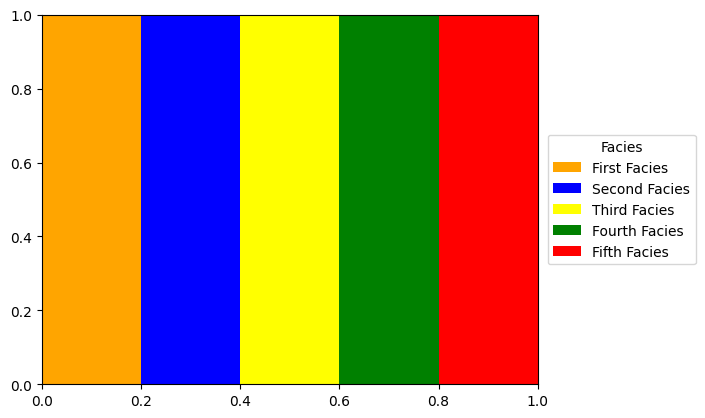

In [11]:
ax = gp.rule(ruleDef, flagLegend=True, flagGaussian=False)

In [12]:
dat


Data Base Characteristics

Data Base Summary
-----------------
File is organized as a set of isolated points
Space dimension              = 2
Number of Columns            = 3
Total number of samples      = 1691

Variables
---------
Column = 0 - Name = X - Locator = x1
Column = 1 - Name = Y - Locator = x2
Column = 2 - Name = LANU - Locator = z1

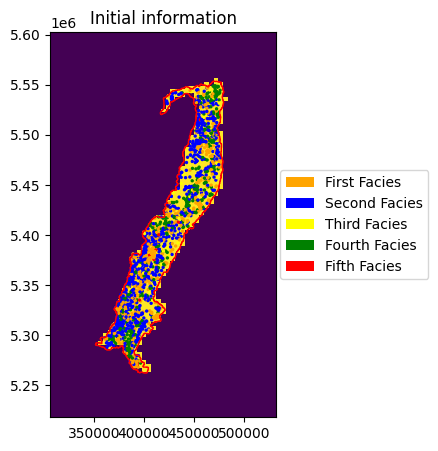

In [13]:
figsize = [8, 5]
fig, ax = gp.init(figsize=figsize, flagEqual=True)
ax.raster(Result, "Polygon", useSel=False)
gp.plot(dat, nameColor="LANU", s=2, flagLegendColor=True, rule=ruleDef)
gp.polygon(poly, linewidth=1, edgecolor="r")
gp.decoration(title="Initial information")

## Computing the proportions

### Compute global proportions (for information)

In [14]:
propGlob = gl.dbStatisticsFacies(dat)
ncat = len(propGlob)
for i in range(ncat):
    print("Proportion of facies " + str(i + 1), "=", round(propGlob[i], 3))

Proportion of facies 1 = 0.273
Proportion of facies 2 = 0.47
Proportion of facies 3 = 0.046
Proportion of facies 4 = 0.205
Proportion of facies 5 = 0.007


### Compute local proportions

In [15]:
model = gl.Model.createFromParam(gl.ECov.MATERN, range=50000.0, param=2.0, sill=1.0)
err = gl.db_proportion_estimate(dat, Result, model)
Result.getStatsAsTable(["Prop.*"])

            Number     Minimum     Maximum        Mean    St. Dev.    Variance
Prop.1     752.000       0.014       0.867       0.267       0.153       0.023
Prop.2     752.000       0.002       0.937       0.481       0.211       0.044
Prop.3     752.000       0.000       0.427       0.053       0.052       0.003
Prop.4     752.000       0.002       0.975       0.193       0.184       0.034
Prop.5     752.000       0.000       0.129       0.007       0.014       0.000

Display the results as Proportion Maps

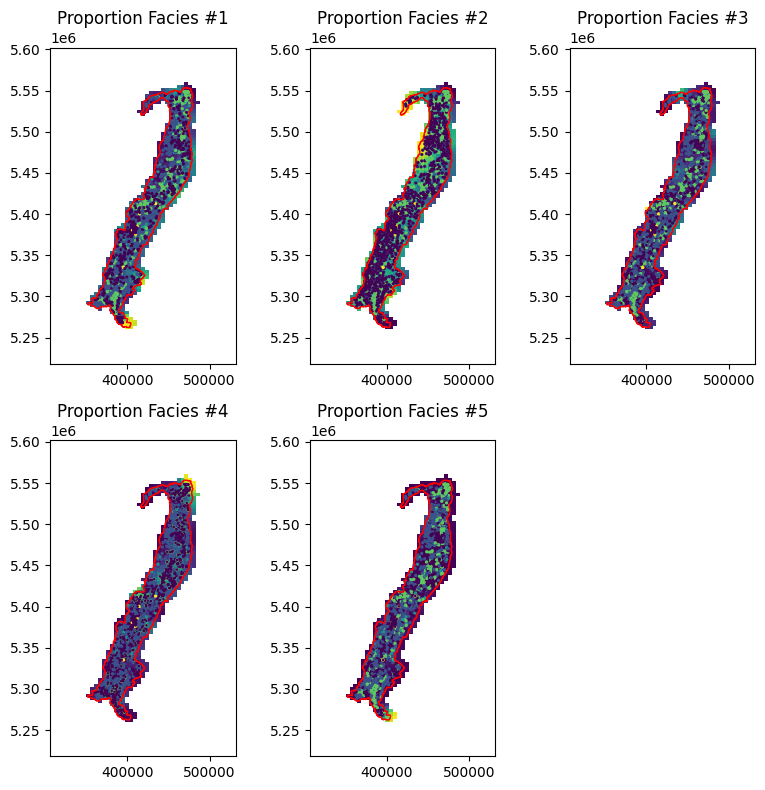

In [16]:
fig, axs = plt.subplots(2, 3, figsize=[8, 8])

for rank, ax in enumerate(axs.flat, start=1):
    if rank > ncat:
        fig.delaxes(ax)
        continue

    ax.raster(Result, name=f"Prop.{rank}")
    ax.decoration(title=f"Proportion Facies #{rank}")
    ax.symbol(dat, nameColor="LANU", s=2, c="black")

    dat.addSelectionByLimit("LANU", gl.Limits((rank, rank)), "SelPoint")
    ax.symbol(dat, nameColor="LANU", s=0.8, c="red")
    dat.deleteColumn("SelPoint")
    ax.polygon(poly, linewidth=1, edgecolor="r")

    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

Creating the environment to infer the Rule. It uses a variogram calculated over very few lags close to the origin.

In [ ]:
varioParam = gl.VarioParam.createOmniDirection(nlag=2, dlag=100)
ruleprop = gl.RuleProp.createFromRuleAndDb(ruleDef, Result)
orderedRules = ruleprop.fit(dat, varioParam, ngrfmax=2)
ngrf = ruleprop.getRule().getNGRF()
print("Number of GRF =", ngrf)
print("Number of Rules (after sorting and merging) =", len(orderedRules))

We plot the first Rules sorted by increasing score.

In [ ]:
rule = orderedRules[0]

In [ ]:
fig, axs = plt.subplots(5, 6, figsize=[10, 8])

for rank, ax in enumerate(axs.flat, start=1):
    rule = orderedRules[rank]
    ax.rule(rule)
    score = rule.getScore()
    ax.text(
        0.02,
        0.98,  # position relative (x,y)
        f"{score:.3f}",  # format : 3 décimales
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        color="red",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )
plt.tight_layout()
plt.show()

In [ ]:
varioParam = gl.VarioParam.createOmniDirection(nlag=19, dlag=1000)
cov = gl.variogram_pgs(dat, varioParam, ruleprop)
if flag_printout:
    cov.display()

We extract the experimental variograms of each GRF.

In [ ]:
vario1 = gl.Vario.createReduce(cov, [0], [], True)
if flag_printout:
    vario1.display()
if ngrf > 1:
    vario2 = gl.Vario(cov)
    vario2.resetReduce([1], [], True)
    if flag_printout:
        vario2.display()

We now fit the model of each GRF considered as independent. 

The fit is performed under the constraint that the sill should be 1.

In [ ]:
constraints = gl.Constraints()
constraints.setConstantSillValue(1.0)
covs = [gl.ECov.MATERN]

modelPGS1 = gl.Model()
modelPGS1.fit(vario1, covs, constraints)
if flag_printout:
    modelPGS1.display()

if ngrf > 1:
    modelPGS2 = gl.Model()
    modelPGS2.fit(vario2, covs, constraints)
    if flag_printout:
        modelPGS2.display()
else:
    modelPGS2 = None

For each GRF, we can plot the experimental variogram as well as the fitted model.

In [ ]:
res = gp.varmod(vario1, modelPGS1)
if ngrf > 1:
    res = gp.varmod(vario2, modelPGS2)

In this paragraph, we compare the experimental indicator variogram to the one derived from the Model of the underlying GRFs.

In [ ]:
varioindic = gl.Vario(varioParam)
err = varioindic.computeIndic(dat)

In [ ]:
varioindic2 = gl.model_pgs(dat, varioParam, ruleprop, modelPGS1, modelPGS2);

On the next figure, we overlay:

- the Variogram of the Indicators (solid line)
- the Variogram derived from the PGS Model (dashed line)

In [ ]:
gp.varmod(varioindic, varioLinestyle="solid")
gp.geometry(dims=[10, 10])
gp.varmod(varioindic2, varioLinestyle="dashed")
gp.close()

We finally perform several simulations of the PGS Model

In [ ]:
neigh = gl.NeighUnique.create()
err = gl.simpgs(dat, Result, ruleprop, modelPGS1, modelPGS2, neigh, nbsimu=4)

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=[10, 8])

for rank, ax in enumerate(axs.flat, start=1):
    ax.raster(Result, name=f"Facies.S{rank}", rule=ruleDef)
    ax.polygon(poly, linewidth=1, edgecolor="r")
    ax.decoration(title=f"Facies #{rank}")
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()